In [4]:
import os as os
import sys
import numpy as np

# adding folders to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd()  , '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

akshat_lisa_root = os.path.abspath(os.path.join(os.getcwd()  , '..',))
if akshat_lisa_root not in sys.path:
    sys.path.insert(0, akshat_lisa_root)

from scripts.readTdi import readTdi
from scripts.wosa import wosa
from scripts.psdNoise import n_time_noise_from_psd, n_noise_psds, compute_psd_noise_distribution
from scripts.plot import plot_psd_noise_histogram

Number of segments: 1
Exiting custom wosa
Number of segments: 16
Exiting custom wosa
Number of segments: 16
Exiting custom wosa
Number of segments: 16
Exiting custom wosa
Number of segments: 16
Exiting custom wosa
Number of segments: 16
Exiting custom wosa
Number of segments: 16
Exiting custom wosa
Number of segments: 16
Exiting custom wosa
Number of segments: 16
Exiting custom wosa
Number of segments: 16
Exiting custom wosa
Number of segments: 16
Exiting custom wosa
Number of segments: 16
Exiting custom wosa
Number of segments: 16
Exiting custom wosa
Number of segments: 16
Exiting custom wosa
Number of segments: 16
Exiting custom wosa
Number of segments: 16
Exiting custom wosa
Number of segments: 16
Exiting custom wosa
Number of segments: 16
Exiting custom wosa
Number of segments: 16
Exiting custom wosa
Number of segments: 16
Exiting custom wosa
Number of segments: 16
Exiting custom wosa
Number of segments: 16
Exiting custom wosa
Number of segments: 16
Exiting custom wosa
Number of se

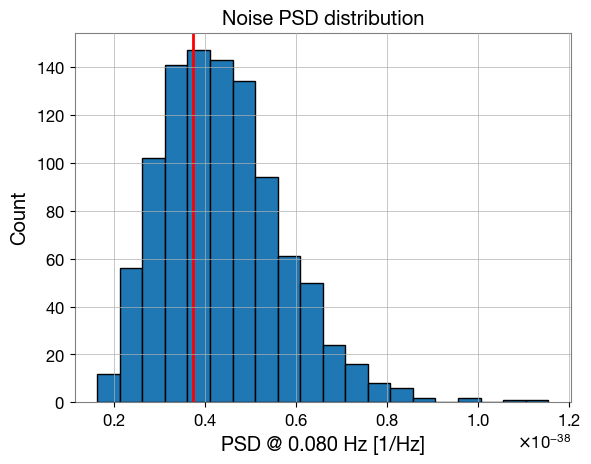

In [9]:
# 1) Read the TDI time series
bethLISA_directory = os.path.join(os.getcwd(), "..", "..", "bethLISA")
tdi_path = os.path.join(bethLISA_directory, 'lisa_glitch_simulation',
                        'tdi_outputs', 'vsmall_glitch_tdi.h5')
data, fs = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 17000
f_orig, orig_psd, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg
) 

# 3) generate n time-domain noise realisations such that PSD equals "PSD OF TDI time series "
time_noises = n_time_noise_from_psd(
    orig_psd, 
    fs, 
    nperseg, 
    n=1000,
    seed_offset=0
)

# 4) Find PSDs of time-domain noise realisations
nperseg_noise = 2000
f_noise, noise_psds = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=1000)

# 5) Choose a 
psd_noise_vals, orig_psd_val, chosen_f_noise = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, 0.8)

# 6) Plot
plot_psd_noise_histogram(
    psd_noise_vals,
    orig_psd_val,
    chosen_f_noise,
    n_bins=20,
    title="Noise PSD distribution"
)